# Quantum Computing Basics with Qiskit

This notebook introduces the core principles of quantum computing using Qiskit.
We will build quantum circuits, print them, and simulate their behavior using a classical backend.

## Classical Bits vs Quantum Bits

- A classical bit can be either `0` or `1`.
- A quantum bit (qubit) can be in a superposition of both `0` and `1` at the same time.
- Qiskit represents qubits with circuits, and the state evolves through gates.

In [2]:
# Import Qiskit and the Aer simulator.
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# Print versions to confirm the environment.
import qiskit
print("Qiskit version:", qiskit.__version__)

Qiskit version: 2.1.2


## Building a Single-Qubit Circuit

A quantum circuit is a sequence of operations acting on qubits.
We'll build a single-qubit circuit and print its diagram.

In [3]:
# Create a single-qubit quantum circuit.
qc = QuantumCircuit(1, 1)
qc.h(0)        # Apply Hadamard gate to put the qubit into superposition.
qc.measure(0, 0)  # Measure the qubit into a classical bit.

# Print the circuit diagram.
print(qc.draw(output='text'))

     ┌───┐┌─┐
  q: ┤ H ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 


## Superposition with the Hadamard Gate

The Hadamard gate puts a qubit into an equal superposition of |0> and |1>.
When measured, the outcome is probabilistic with roughly equal chance for each result.

In [4]:
# Simulate the circuit using the Aer simulator.
simulator = AerSimulator()
compiled = transpile(qc, simulator)
result = simulator.run(compiled, shots=1000).result()
counts = result.get_counts()

print("Measurement counts:", counts)

Measurement counts: {'1': 474, '0': 526}


## Single-Qubit Pauli Gates

Common quantum gates on a single qubit:

- `x`: flips |0> and |1>
- `y`: flips and adds a phase
- `z`: flips the sign of the |1> amplitude

We'll build circuits for these gates and print their diagrams.

In [5]:
# Create circuits for X, Y, and Z gates.
qc_x = QuantumCircuit(1, 1)
qc_x.x(0)
qc_x.measure(0, 0)

qc_y = QuantumCircuit(1, 1)
qc_y.y(0)
qc_y.measure(0, 0)

qc_z = QuantumCircuit(1, 1)
qc_z.h(0)
qc_z.z(0)
qc_z.h(0)
qc_z.measure(0, 0)

print("X gate circuit:\n", qc_x.draw(output='text'))
print("Y gate circuit:\n", qc_y.draw(output='text'))
print("Z gate circuit (in the computational basis):\n", qc_z.draw(output='text'))

X gate circuit:
      ┌───┐┌─┐
  q: ┤ X ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 
Y gate circuit:
      ┌───┐┌─┐
  q: ┤ Y ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 
Z gate circuit (in the computational basis):
      ┌───┐┌───┐┌───┐┌─┐
  q: ┤ H ├┤ Z ├┤ H ├┤M├
     └───┘└───┘└───┘└╥┘
c: 1/════════════════╩═
                     0 


## Multi-Qubit States and Entanglement

Two-qubit systems can represent entangled states that have no separate description for each qubit.
We'll create a Bell state using a Hadamard gate and a CNOT gate.

In [6]:
# Build a 2-qubit Bell state circuit.
bell = QuantumCircuit(2, 2)
bell.h(0)        # Create superposition on the first qubit.
bell.cx(0, 1)    # Entangle the second qubit with the first.
bell.measure([0, 1], [0, 1])

print(bell.draw(output='text'))

     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 


## Bell State Measurement

The Bell state \(|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)\)
produces perfectly correlated measurement outcomes: either `00` or `11`.

We will simulate the circuit and inspect the counts.

In [7]:
# Simulate the Bell state circuit.
compiled_bell = transpile(bell, simulator)
bell_result = simulator.run(compiled_bell, shots=1000).result()
bell_counts = bell_result.get_counts()

print("Bell state measurement counts:", bell_counts)

Bell state measurement counts: {'11': 505, '00': 495}


## Visualizing Results

We can also display the measurement histogram to see the probability distribution.
If running in a notebook with a display backend, the plot will appear inline.

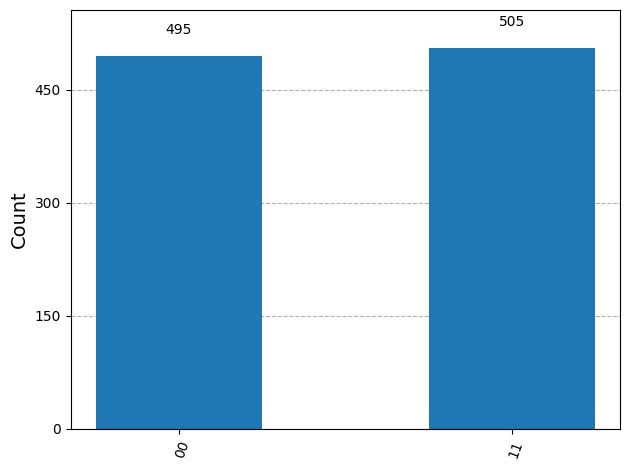

In [9]:
# Display the histogram for the Bell state.
try:
    display(plot_histogram(bell_counts))
except Exception as error:
    print("Could not display histogram inline. Counts: {}".format(bell_counts))

## Key Concepts Learned

- Qiskit expresses quantum operations as `QuantumCircuit` objects.
- The Hadamard gate creates superposition, leading to probabilistic measurement outcomes.
- Pauli gates manipulate qubit amplitudes and phases.
- Entanglement is created with a Hadamard plus CNOT, producing correlated outcomes.
- Simulators such as `aer_simulator` let us run circuits on classical hardware.

This notebook is ready to be extended with more advanced quantum algorithms and hybrid quantum-classical ideas.